# TI IWR6843 Fall Detection — Representation 1: Micro-Doppler Spectrogram (ResNet-18)

Trains PyTorch **ResNet-18** on **Micro-Doppler Spectrogram** tensors (Density, Energy, Velocity Gradient).

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

sns.set_theme(style="whitegrid")
torch.manual_seed(42)

preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../../datasets/preprocessed")

X_rep1 = np.load(preproc_dir / "X_rep1_spectrogram_ti.npy")
y_rep1 = np.load(preproc_dir / "y_rep1_spectrogram_ti.npy")

print(f"Loaded Representation 1 Spectrogram Tensor: {X_rep1.shape}")
print(f"Labels: {np.bincount(y_rep1.astype(int))} (0 = ADL, 1 = Fall)")

Loaded Representation 1 Spectrogram Tensor: (728, 3, 64, 64)
Labels: [364 364] (0 = ADL, 1 = Fall)


In [2]:
# ResNet-18 Kinematic Model Architecture
class ResNet18Spectrogram(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ResNet18Spectrogram, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        feat = self.features(x).view(x.size(0), -1)
        return self.fc(feat)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18Spectrogram().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [3]:
# Train/Test Split & Best Model Checkpointing
X_tr, X_te, y_tr, y_te = train_test_split(X_rep1, y_rep1, test_size=0.2, random_state=42, stratify=y_rep1)
tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
te_ds = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

# Best Model Checkpoint Path
models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "resnet18_rep1_spectrogram_ti.pth"

epochs = 15
best_val_loss = float('inf')

for ep in range(epochs):
    model.train()
    tot_loss, corr, tot = 0.0, 0, 0
    for bx, by in tr_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        tot_loss += loss.item() * bx.size(0)
        corr += (out.argmax(1) == by).sum().item()
        tot += by.size(0)
    train_loss = tot_loss / tot
    train_acc = corr / tot

   # Validation step to track best model
    model.eval()
    val_loss, val_corr, val_tot = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in te_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            v_loss = criterion(out, by)
            val_loss += v_loss.item() * bx.size(0)
            val_corr += (out.argmax(1) == by).sum().item()
            val_tot += by.size(0)
    val_loss /= val_tot
    val_acc = val_corr / val_tot

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " [BEST SAVED]"
    else:
        saved_flag = ""

    if (ep + 1) % 5 == 0 or ep == 0 or saved_flag:
        print(f"Epoch {ep+1:02d}/{epochs} - Tr Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%{saved_flag}")

# Reload best model weights for evaluation
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model checkpoint from: {best_model_path} (Best Val Loss: {best_val_loss:.4f})")

Epoch 01/15 - Tr Loss: 0.6594 Acc: 62.71% | Val Loss: 0.7084 Acc: 50.00% [BEST SAVED]


Epoch 02/15 - Tr Loss: 0.5772 Acc: 71.82% | Val Loss: 0.6149 Acc: 73.97% [BEST SAVED]


Epoch 03/15 - Tr Loss: 0.5018 Acc: 77.49% | Val Loss: 0.5706 Acc: 67.81% [BEST SAVED]


Epoch 04/15 - Tr Loss: 0.4480 Acc: 78.35% | Val Loss: 0.3960 Acc: 84.93% [BEST SAVED]


Epoch 05/15 - Tr Loss: 0.3747 Acc: 84.88% | Val Loss: 1.6793 Acc: 51.37%


Epoch 10/15 - Tr Loss: 0.2233 Acc: 91.07% | Val Loss: 0.3123 Acc: 87.67% [BEST SAVED]


Epoch 11/15 - Tr Loss: 0.2081 Acc: 92.44% | Val Loss: 0.3121 Acc: 86.99% [BEST SAVED]


Epoch 15/15 - Tr Loss: 0.1019 Acc: 97.08% | Val Loss: 2.8588 Acc: 56.85%

Loaded best model checkpoint from: ..\..\models\resnet18_rep1_spectrogram_ti.pth (Best Val Loss: 0.3121)


--- Representation 1 (Spectrogram ResNet-18) Test Results ---
Test Accuracy: 86.99%
ROC-AUC Score: 0.9415

Classification Report:
                  precision    recall  f1-score   support

 ADL (Non-Fall)       0.89      0.85      0.87        73
           Fall       0.86      0.89      0.87        73

       accuracy                           0.87       146
      macro avg       0.87      0.87      0.87       146
   weighted avg       0.87      0.87      0.87       146



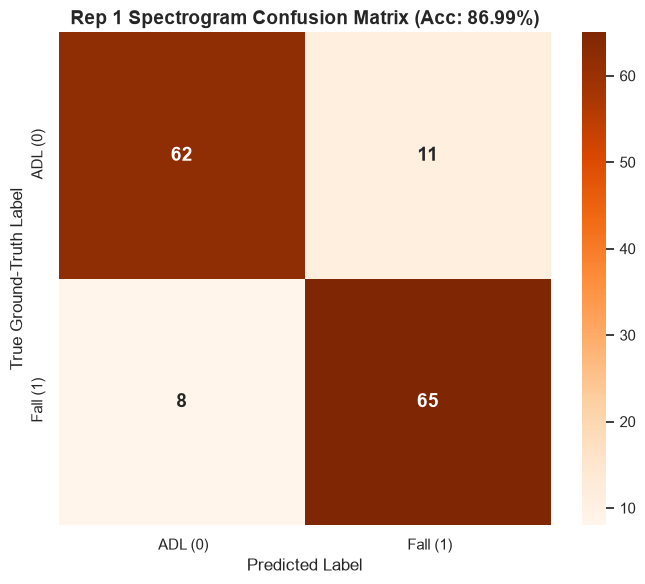

In [4]:
# Evaluate on Test Set
model.eval()
preds_list, probs_list, targets_list = [], [], []
with torch.no_grad():
    for bx, by in te_loader:
        bx = bx.to(device)
        out = model(bx)
        prob = torch.softmax(out, dim=1)[:, 1]
        preds_list.extend(out.argmax(dim=1).cpu().numpy())
        probs_list.extend(prob.cpu().numpy())
        targets_list.extend(by.numpy())

targets_arr = np.array(targets_list)
preds_arr = np.array(preds_list)
probs_arr = np.array(probs_list)

acc = accuracy_score(targets_arr, preds_arr)
auc = roc_auc_score(targets_arr, probs_arr)
cm = confusion_matrix(targets_arr, preds_arr)

print(f"--- Representation 1 (Spectrogram ResNet-18) Test Results ---")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC-AUC Score: {auc:.4f}")
print("\nClassification Report:\n", classification_report(targets_arr, preds_arr, target_names=[" ADL (Non-Fall)", " Fall"]))

# Visual Confusion Matrix Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[" ADL (0)", " Fall (1)"],
            yticklabels=[" ADL (0)", " Fall (1)"],
            annot_kws={"size": 14, "weight": "bold"})
plt.title(f"Rep 1 Spectrogram Confusion Matrix (Acc: {acc*100:.2f}%)", fontweight="bold", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Ground-Truth Label", fontsize=12)
plt.tight_layout()
plt.show()
